The concat() function concatenates an arbitrary amount of Series or DataFrame objects along an axis while performing optional set logic (union or intersection) of the indexes on the other axes. Like numpy.concatenate, concat() takes a list or dict of homogeneously-typed objects and concatenates them.

In [ ]:
import pandas as pd
df1 = pd.DataFrame(
    {
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    },
    index=[0, 1, 2, 3],
)


df2 = pd.DataFrame(
    {
        "A": ["A4", "A5", "A6", "A7"],
        "B": ["B4", "B5", "B6", "B7"],
        "C": ["C4", "C5", "C6", "C7"],
        "D": ["D4", "D5", "D6", "D7"],
    },
    index=[4, 5, 6, 7],
)


df3 = pd.DataFrame(
    {
        "A": ["A8", "A9", "A10", "A11"],
        "B": ["B8", "B9", "B10", "B11"],
        "C": ["C8", "C9", "C10", "C11"],
        "D": ["D8", "D9", "D10", "D11"],
    },
    index=[8, 9, 10, 11],
)


frames = [df1, df2, df3]

result = pd.concat(frames)

result

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7
8,A8,B8,C8,D8
9,A9,B9,C9,D9


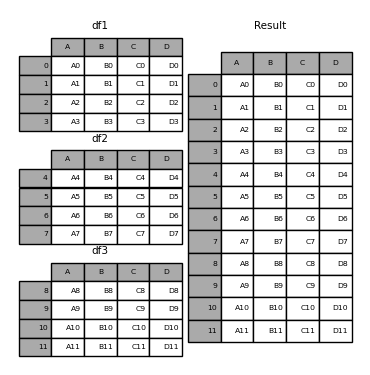

concat() makes a full copy of the data, and iteratively reusing concat() can create unnecessary copies. Collect all DataFrame or Series objects in a list before using concat().

When concatenating DataFrame with named axes, pandas will attempt to preserve these index/column names whenever possible. In the case where all inputs share a common name, this name will be assigned to the result. When the input names do not all agree, the result will be unnamed. The same is true for MultiIndex, but the logic is applied separately on a level-by-level basis.

**Joining logic of the resulting axis**

The join keyword specifies how to handle axis values that don’t exist in the first DataFrame.

join='outer' takes the union of all axis values

In [ ]:
df4 = pd.DataFrame(
    {
        "B": ["B2", "B3", "B6", "B7"],
        "D": ["D2", "D3", "D6", "D7"],
        "F": ["F2", "F3", "F6", "F7"],
    },
    index=[2, 3, 6, 7],
)

result = pd.concat([df1, df4], axis=1)

result

,A,B,C,D,B,D,F
0,A0,B0,C0,D0,NaN,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN,NaN
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3
6,NaN,NaN,NaN,NaN,B6,D6,F6
7,NaN,NaN,NaN,NaN,B7,D7,F7


join='inner' takes the intersection of the axis values

In [ ]:
result = pd.concat([df1, df4], axis=1, join="inner")

result

,A,B,C,D,B,D,F
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3


To perform an effective “left” join using the exact index from the original DataFrame, result can be reindexed.

In [ ]:
result = pd.concat([df1, df4], axis=1).reindex(df1.index)

result

,A,B,C,D,B,D,F
0,A0,B0,C0,D0,NaN,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN,NaN
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3


**Ignoring indexes on the concatenation axis**


For DataFrame objects which don’t have a meaningful index, the ignore_index ignores overlapping indexes.

In [ ]:
result = pd.concat([df1, df4], ignore_index=True, sort=False)

result

,A,B,C,D,F
0,A0,B0,C0,D0,NaN
1,A1,B1,C1,D1,NaN
2,A2,B2,C2,D2,NaN
3,A3,B3,C3,D3,NaN
4,NaN,B2,NaN,D2,F2
5,NaN,B3,NaN,D3,F3
6,NaN,B6,NaN,D6,F6
7,NaN,B7,NaN,D7,F7


**Concatenating Series and DataFrame together**


You can concatenate a mix of Series and DataFrame objects. The Series will be transformed to DataFrame with the column name as the name of the Series.

In [ ]:
s1 = pd.Series(["X0", "X1", "X2", "X3"], name="X")

result = pd.concat([df1, s1], axis=1)

result

,A,B,C,D,X
0,A0,B0,C0,D0,X0
1,A1,B1,C1,D1,X1
2,A2,B2,C2,D2,X2
3,A3,B3,C3,D3,X3
